In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("diabetes.csv")

In [4]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
128,1,117,88.0,24,145.0,34.5,0.403,40,1
173,1,79,60.0,42,48.0,43.5,0.678,23,0
623,0,94,70.0,27,115.0,43.5,0.347,21,0
511,0,139,62.0,17,210.0,22.1,0.207,21,0
673,3,123,100.0,35,240.0,57.3,0.880,22,0


| Feature                      | What the value represents         | Used for                     |
| ---------------------------- | --------------------------------- | ---------------------------- |
| **Pregnancies**              | Number of times pregnant          | Pregnancy history            |
| **Glucose**                  | Blood glucose level               | Blood sugar status           |
| **BloodPressure**            | Diastolic blood pressure          | Blood pressure status        |
| **SkinThickness**            | Thickness of skin fold            | Body fat estimation          |
| **Insulin**                  | Insulin level in blood            | Insulin response             |
| **BMI**                      | Body Mass Index                   | Body weight/body composition |
| **DiabetesPedigreeFunction** | Family-history diabetes score     | Genetic/family risk          |
| **Age**                      | Person's age                      | Age-related diabetes risk    |
| **Outcome**                  | `0` = no diabetes, `1` = diabetes | **Target/prediction**        |


In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt



## Glucose

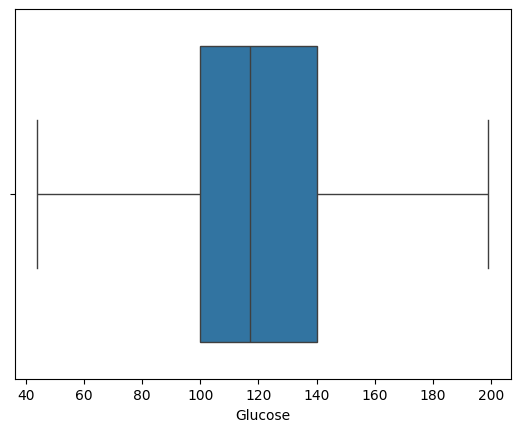

In [10]:
sns.boxplot(x=df["Glucose"])
plt.show()

In [11]:
df["Glucose"].describe()

count    768.000000
mean     121.677083
std       30.464161
min       44.000000
25%       99.750000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

In [12]:
(df["Glucose"] == 0).sum()

np.int64(0)

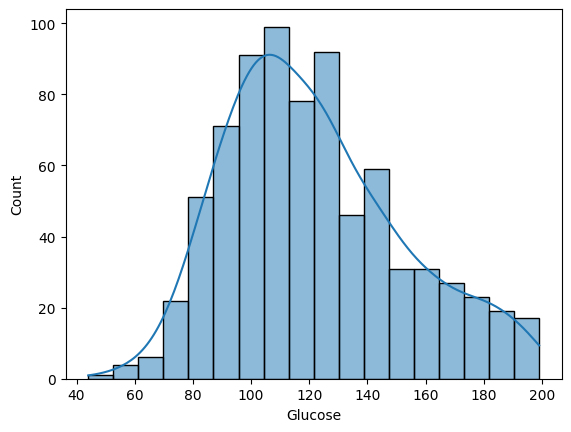

In [13]:
sns.histplot(df["Glucose"], kde=True)
plt.show()

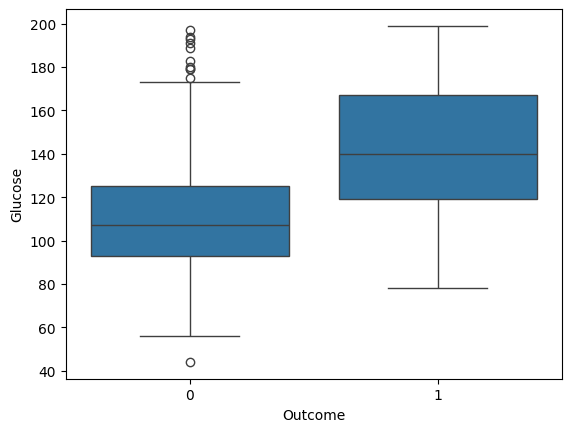

In [14]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()

In [15]:
df[df["Outcome"] == 0]["Glucose"].describe()

count    500.00000
mean     110.62200
std       24.70392
min       44.00000
25%       93.00000
50%      107.00000
75%      125.00000
max      197.00000
Name: Glucose, dtype: float64

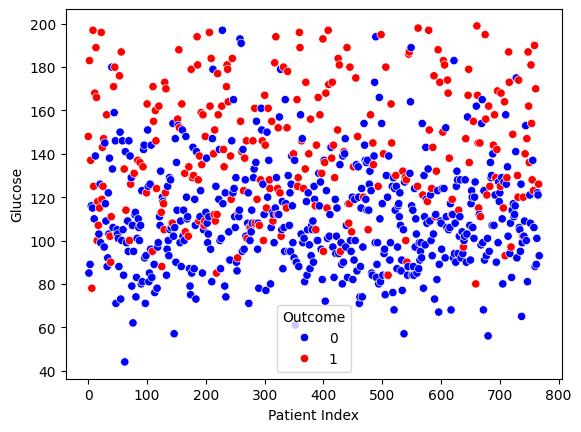

In [16]:
sns.scatterplot(
    data=df,
    x=df.index,
    y="Glucose",
    hue="Outcome",
    palette={0: "blue", 1: "red"}
)

plt.xlabel("Patient Index")
plt.ylabel("Glucose")
plt.show()

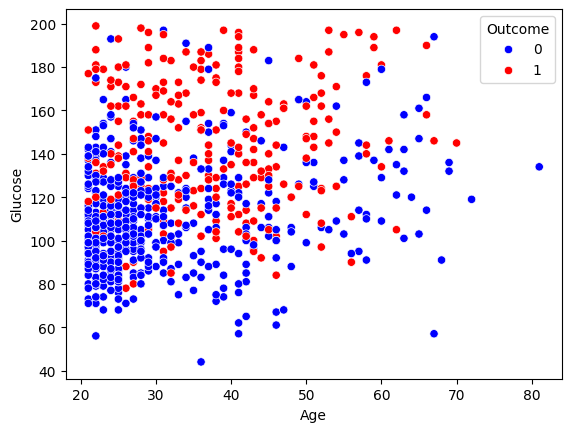

In [17]:
sns.scatterplot(
    data=df,
    x="Age",
    y="Glucose",
    hue="Outcome",
    palette={0: "blue", 1: "red"}
)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.show()

## BloodPressure

In [18]:

df["BloodPressure"].describe()

count    768.000000
mean      72.389323
std       12.106039
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

In [24]:
df['Glucose'].corr(df["Outcome"]) # moderate corelation with outcome

np.float64(0.49599047660231554)

In [19]:
(df["BloodPressure"] == 0).sum()

np.int64(0)

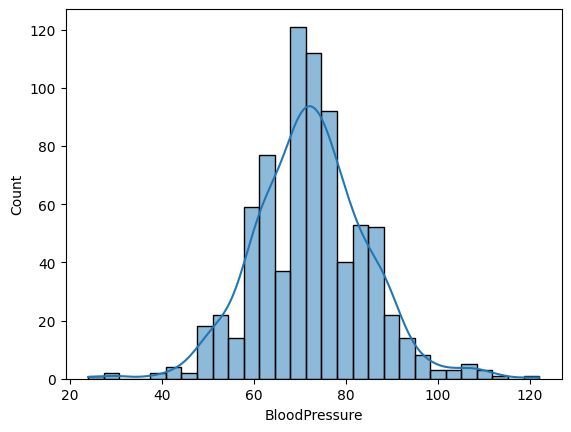

In [20]:
sns.histplot(df["BloodPressure"], kde=True)
plt.show()

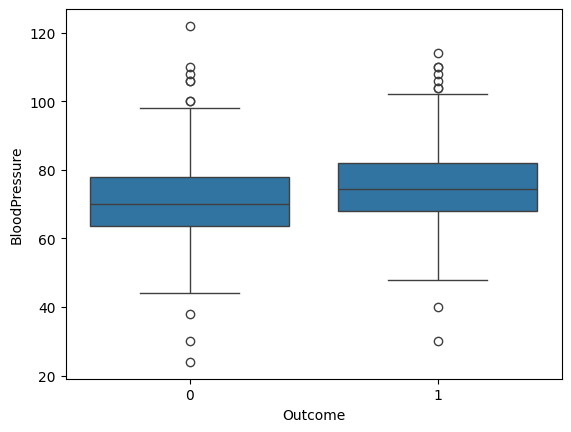

In [21]:
sns.boxplot(data=df, x="Outcome", y="BloodPressure")
plt.show()

In [23]:
df["BloodPressure"].corr(df["Outcome"]) # weak relation 0.175

np.float64(0.17446877244887277)

## SkinThickness

In [25]:
df["SkinThickness"].describe()

count    768.000000
mean      29.089844
std        8.890820
min        7.000000
25%       25.000000
50%       28.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

In [26]:
(df["SkinThickness"] == 0).sum()

np.int64(0)

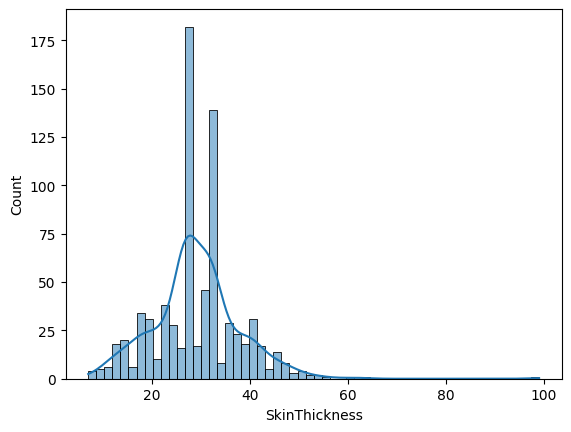

In [27]:
sns.histplot(df["SkinThickness"], kde=True)
plt.show()

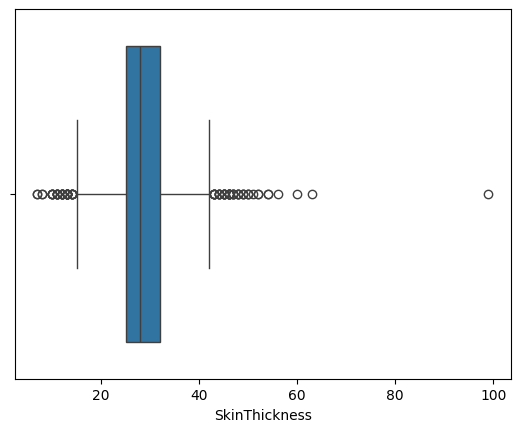

In [29]:
sns.boxplot(x=df["SkinThickness"])
plt.show()

In [30]:
df["SkinThickness"].corr(df["Outcome"])

np.float64(0.29513764691994454)

## Insulin

In [31]:
df["Insulin"].describe()

count    768.000000
mean     141.753906
std       89.100847
min       14.000000
25%      102.500000
50%      102.500000
75%      169.500000
max      846.000000
Name: Insulin, dtype: float64

In [32]:
(df["Insulin"] == 0).sum()

np.int64(0)

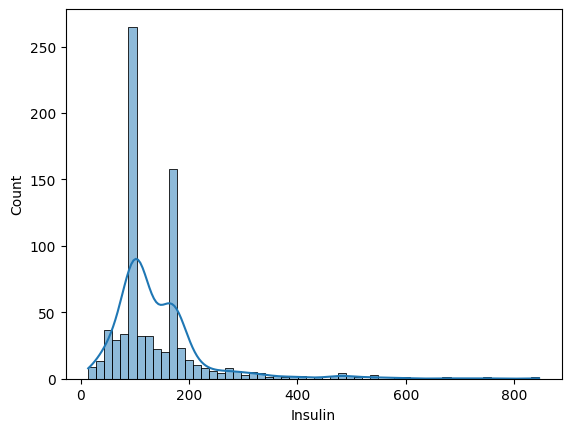

In [33]:
sns.histplot(df["Insulin"], kde=True)
plt.show()

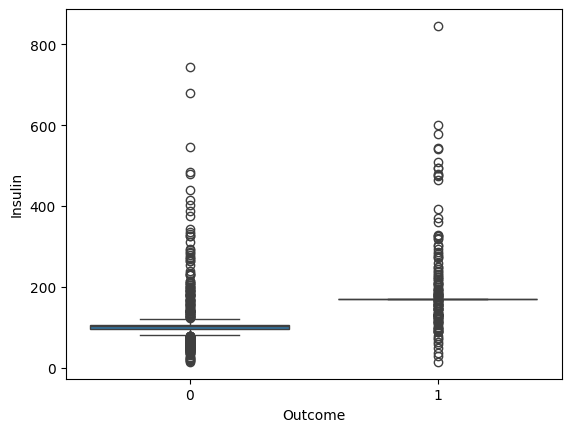

In [34]:
sns.boxplot(data=df, x="Outcome", y="Insulin")
plt.show()

## BMI


In [35]:
df["BMI"].describe()

count    768.000000
mean      32.434635
std        6.880498
min       18.200000
25%       27.500000
50%       32.050000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

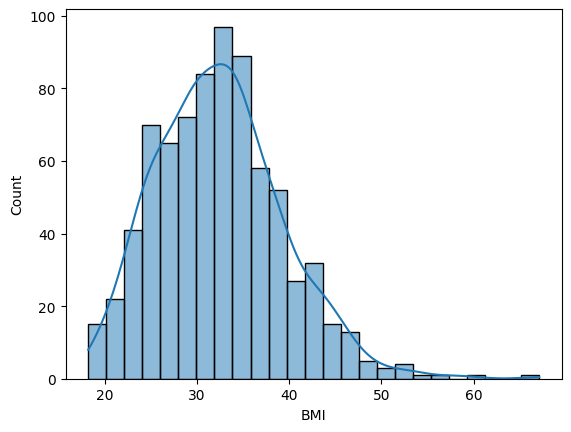

In [36]:
sns.histplot(df["BMI"], kde=True)
plt.show()

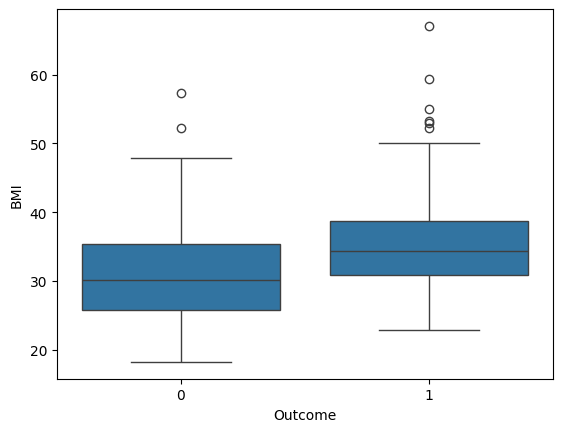

In [37]:
sns.boxplot(data=df, x="Outcome", y="BMI")
plt.show()

In [38]:
df["BMI"].corr(df["Outcome"])

np.float64(0.31557668766914887)

## DiabetesPedigreeFunction

In [39]:
df["DiabetesPedigreeFunction"].describe()

count    768.000000
mean       0.471876
std        0.331329
min        0.078000
25%        0.243750
50%        0.372500
75%        0.626250
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64

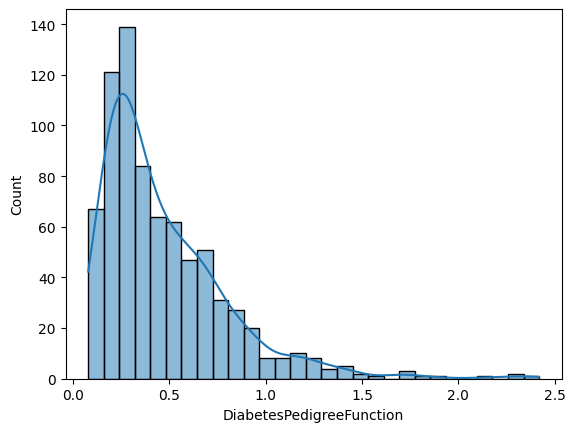

In [40]:
sns.histplot(df["DiabetesPedigreeFunction"], kde=True)
plt.show()

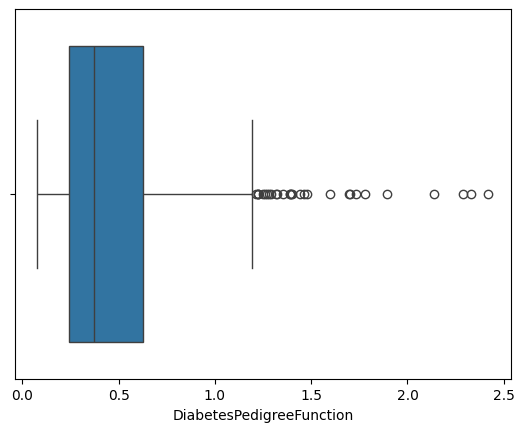

In [41]:
sns.boxplot(x=df["DiabetesPedigreeFunction"])
plt.show()

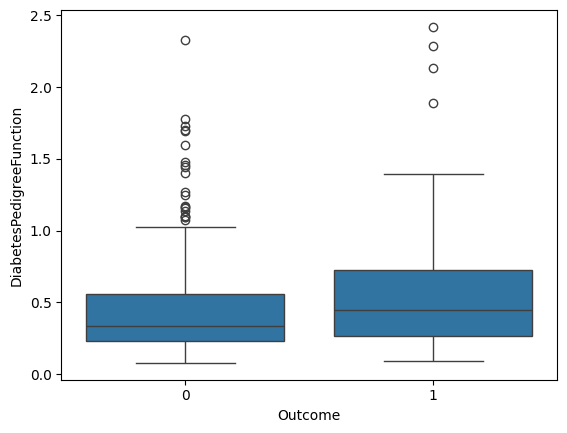

In [42]:
sns.boxplot(data=df, x="Outcome", y="DiabetesPedigreeFunction")
plt.show()

In [43]:
df["DiabetesPedigreeFunction"].corr(df["Outcome"])

np.float64(0.17384406565295973)

## Age

In [44]:
df["Age"].describe()

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

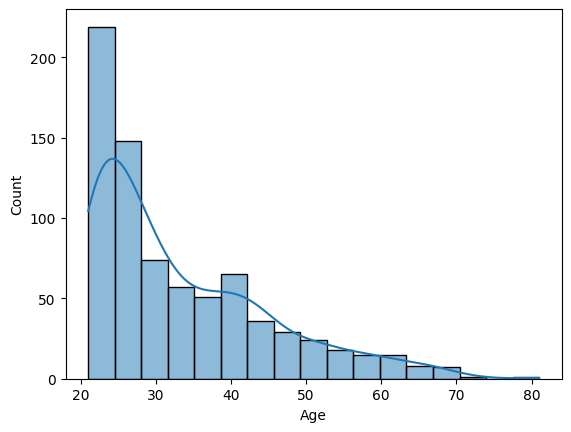

In [45]:
sns.histplot(df["Age"], kde=True)
plt.show()

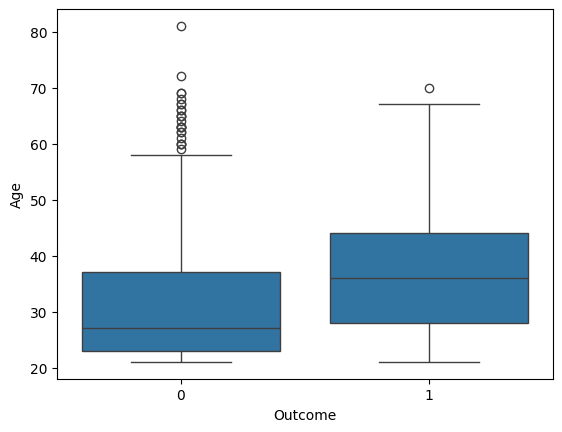

In [46]:
sns.boxplot(data=df, x="Outcome", y="Age")
plt.show()

In [47]:
df["Age"].corr(df["Outcome"])

np.float64(0.23835598302719768)

## Pregnancies

In [48]:
df["Pregnancies"].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

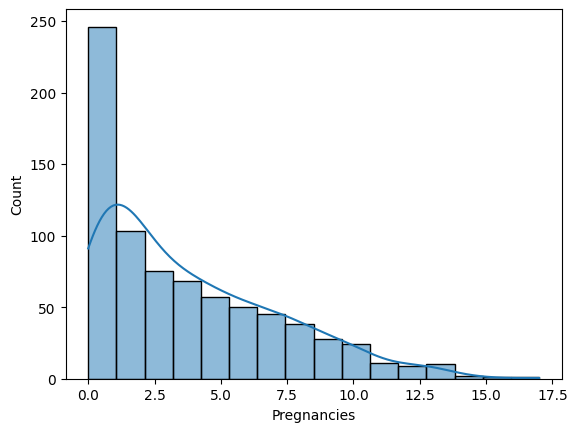

In [49]:
sns.histplot(df["Pregnancies"], kde=True)
plt.show()

In [50]:
df["Pregnancies"].corr(df["Outcome"])

np.float64(0.22189815303398652)

In [51]:
corr = df.corr(numeric_only=True)
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130155,0.209151,0.089028,0.058767,0.023890,-0.033523,0.544341,0.221898
Glucose,0.130155,1.000000,0.225141,0.229289,0.490015,0.236171,0.138353,0.268910,0.495990
BloodPressure,0.209151,0.225141,1.000000,0.199349,0.070128,0.286399,-0.001443,0.325135,0.174469
SkinThickness,0.089028,0.229289,0.199349,1.000000,0.200129,0.566086,0.106280,0.129537,0.295138
Insulin,0.058767,0.490015,0.070128,0.200129,1.000000,0.238443,0.146878,0.123629,0.377081
BMI,0.023890,0.236171,0.286399,0.566086,0.238443,1.000000,0.152771,0.027849,0.315577
DiabetesPedigreeFunction,-0.033523,0.138353,-0.001443,0.106280,0.146878,0.152771,1.000000,0.033561,0.173844
Age,0.544341,0.268910,0.325135,0.129537,0.123629,0.027849,0.033561,1.000000,0.238356
Outcome,0.221898,0.495990,0.174469,0.295138,0.377081,0.315577,0.173844,0.238356,1.000000


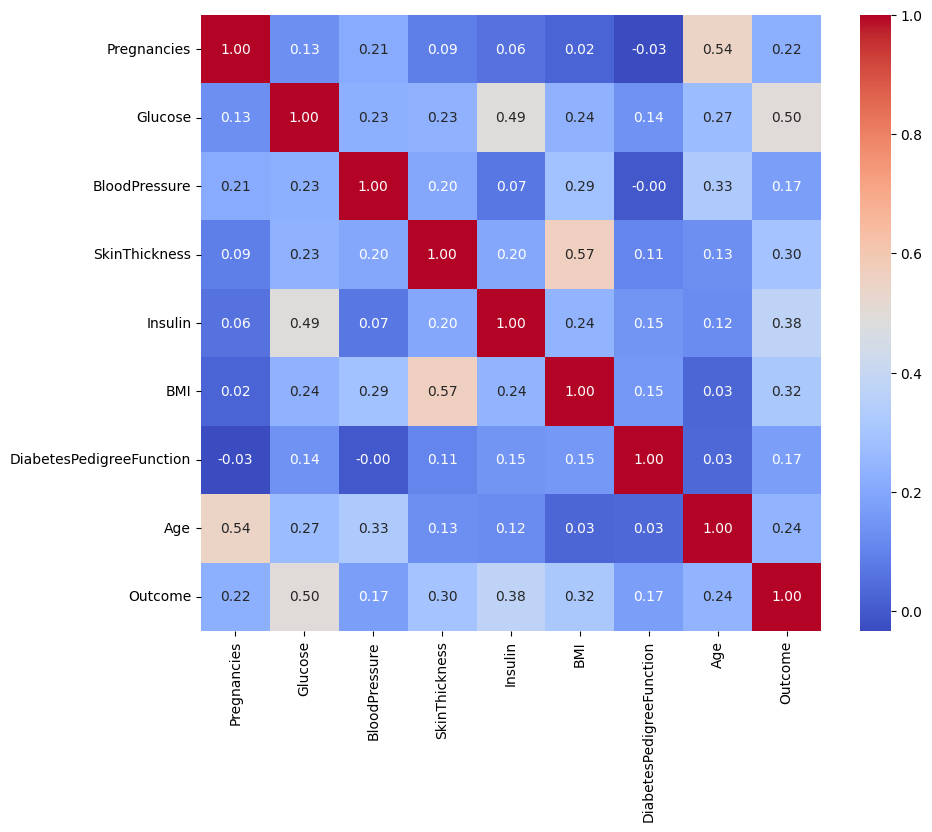

In [52]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [53]:
df.corr(numeric_only=True)["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64

## train test split

In [54]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

In [57]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [58]:
y_pred = pipe.predict(X_test)

In [61]:
y_prob = pipe.predict_proba(X_test)[:, 1]

In [62]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7077922077922078

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [67]:
print(confusion_matrix(y_test, y_pred))

[[79 21]
 [24 30]]
